## 11. Differentialgleichungen

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=HReAo38LoM4&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience11.png)](https://www.youtube.com/watch?v=HReAo38LoM4&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Spezielle Gleichungstypen mit Differentialtermen entstehen aus grundlegenden Beziehungen wie Masse-, Energie- und Impulserhaltung.
Beispiel: Die Massenakkumulation $\frac{dm}{dt}$ in einem Kontrollvolumen ist gleich dem Masseneintritt $\dot m_{in}$ minus dem Massenaustritt $\dot m_{out}$ aus diesem Volumen.

$\frac{dm}{dt} = \dot m_{in} - \dot m_{out}$

Dynamische Modelle können entweder aus Daten identifiziert (regressiert) oder datenfrei aus grundlegenden Beziehungen abgeleitet werden. Auch bei grundlegenden Beziehungen können Parameter unbekannt oder unsicher sein. Ein kombinierter Ansatz zur Modellierung dynamischer Systeme ist, physikbasierte Grundgleichungen mit Data-Science zu verbinden. Dieser Ansatz nutzt die Stärken beider Methoden: Er erzeugt ein Modell, das sich an Messwerte anpasst und in Bereiche extrapoliert, in denen es keine oder nur wenige Daten gibt.

![exercise](https://apmonitor.com/che263/uploads/Begin_Python/exercise.png)

Die erste Übung besteht darin, [Differentialgleichungen zu lösen](https://apmonitor.com/pdc/index.php/Main/SolveDifferentialEquations) (mehrere Beispiele mit ``odeint``). Dieselben Beispiele werden auch [mit Gekko gelöst](https://apmonitor.com/pdc/index.php/Main/PythonDifferentialEquations).
Für Simulation liefern beide gleichwertige Ergebnisse, aber Gekko ist darauf ausgelegt, Differentialgleichungen in Optimierung oder in Kombination mit Machine Learning zu nutzen. Die Funktion ``odeint`` hat den spezifischen Zweck, gewöhnliche Differentialgleichungen (ODEs) zu lösen. Sie erfordert 3 Eingaben.

    y = odeint(model, y0, t)

1. ``model`` – Funktionsname, der bei gegebenen Werten für ``y`` und ``t`` die Ableitungen  ``dydt = model(y, t)`` zurückgibt

2. ``y0`` – Anfangsbedingungen der Differentialzustände

3. ``t`` – Zeitpunkte, an denen die Lösung ausgegeben wird



![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Differentialgleichungen lösen

Wir lösen die Differentialgleichung mit der Anfangsbedingung

$y(0) = 5$:

$ k \, \frac{dy}{dt} = -y$

wobei $k=10$. Die Lösung von `y` wird für die Zeit von `0` bis `20`ausgegeben und als Plot von $y(t)$ gegen $t$ dargestellt. Beachte, wie die Gleichung so umgestellt wird, dass die Funktion nur den Ableitungswert zurückgibt: `dydt = -(1.0/k) * y` 

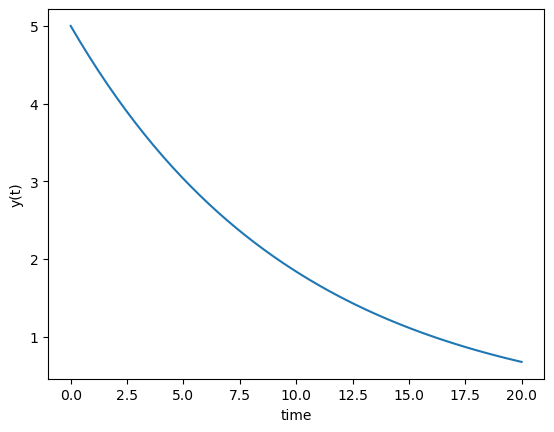

In [1]:
import numpy as np
from scipy.integrate import odeint

# Funktion, die dy/dt zurückgibt
def model(y,t):
    k = 10.0
    dydt = -(1.0/k) * y
    return dydt

y0 = 5                 # Anfangsbedingung
t = np.linspace(0,20)  # Zeitpunkte
y = odeint(model,y0,t) # ODE lösen

import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(t,y)
plt.xlabel('time'); plt.ylabel('y(t)')
plt.show()

![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

### Differentialgleichungen mit GEKKO lösen

[Python Gekko](https://gekko.readthedocs.io/en/latest/) löst dasselbe Differentialgleichungsproblem. Gekko ist für großskalige Probleme ausgelegt. [Weitere Gekko-Tutorials](https://apmonitor.com/wiki/index.php/Main/GekkoPythonOptimization) zeigen, wie man andere Gleichungstypen und Optimierungsprobleme löst.

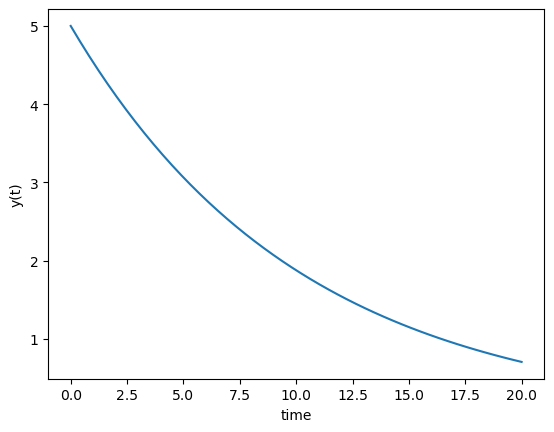

In [2]:
from gekko import GEKKO

m = GEKKO(remote=False)    # GEKKO-Modell
m.time = np.linspace(0,20) # Zeitpunkte
y = m.Var(5.0); k = 10.0   # GEKKO-Variable und -Konstante
m.Equation(k*y.dt()+y==0)  # GEKKO-Gleichung

m.options.IMODE = 4        # Dynamische Simulation
m.solve(disp=False)        # Lösen

plt.plot(m.time,y)
plt.xlabel('time'); plt.ylabel('y(t)')
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Übung zu Differentialgleichungen

Löse die Differentialgleichung mit Anfangsbedingung $y(0) = 10$:

$ k \, \frac{dy}{dt} = -y$

Vergleiche die fünf Lösungen von ``𝑦``für die Zeit von 
``0`` bis ``20`` mit `k=[1,2,5,10,20]`.

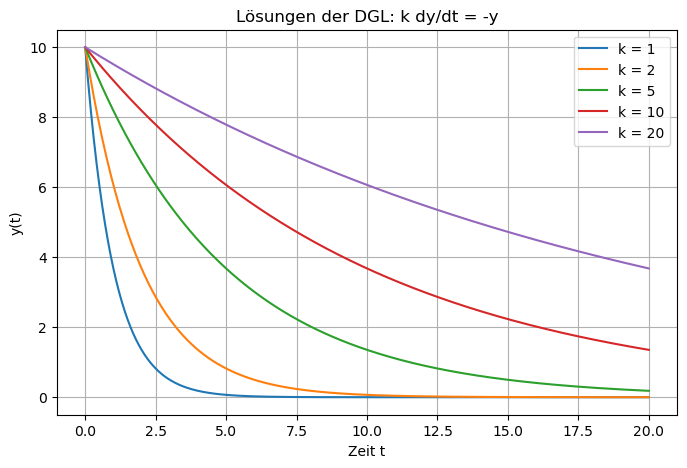

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Anfangsbedingung
y0 = 10

# Zeitbereich
t = np.linspace(0, 20, 400)

# k-Werte
k_values = [1, 2, 5, 10, 20]

plt.figure(figsize=(8,5))

for k in k_values:
    # Analytische Lösung:
    # k dy/dt = -y  ->  dy/dt = -(1/k)y
    # Lösung: y(t) = y0 * exp(-t/k)
    y = y0 * np.exp(-t / k)
    plt.plot(t, y, label=f'k = {k}')

plt.xlabel('Zeit t')
plt.ylabel('y(t)')
plt.title('Lösungen der DGL: k dy/dt = -y')
plt.legend()
plt.grid(True)
plt.show()

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Symbolische Lösung

Kompakte Differentialgleichungsprobleme können eine analytische Lösung haben, die sich symbolisch ausdrücken lässt. Ein symbolisches Mathematikpaket in Python ist `sympy`. Sympy bestimmt die analytische Lösung als $y(x)=C_1 \, \exp{\left(-\frac{x}{k}\right)}$. Mit der Anfangsbedingung $y(0)=5$ gilt $C_1=5$.


In [4]:
from IPython.display import display
import sympy as sym
from sympy.abc import x, k
y = sym.Function('y')
ans = sym.dsolve(sym.Derivative(y(x), x) + y(x)/k, y(x))
display(ans)

Eq(y(x), C1*exp(-x/k))

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Differentialgleichungen mit Input `u` lösen

Differentialgleichungen können auch eine Eingabe (Feature) haben, die sich durch eine externe Quelle (exogenous input) ändert – etwa aktiv durch einen Messsensor, manuell durch eine Person oder automatisch durch einen Computer.

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

Berechne die Antwort `y(t)` wenn der Eingang ``𝑢``sich bei `t=5` von`0` auf `2` ändert.

$2 \frac{dy(t)}{dt} + y(t) = u(t)$

Die Anfangsbedingung ist `y(0)=1` und die Lösung soll bis `t=15` berechnet werden. **Tipp**: Der Ausdruck `y(t)` bedeutet nicht `y` mal `t`. Er zeigt an, dass sich `y` mit der Zeit ändert und als Funktion der Zeit geschrieben wird. Zusätzliche Beispiele findest du [hier](https://apmonitor.com/pdc/index.php/Main/SolveDifferentialEquations) für ODEINT und  [hier](https://apmonitor.com/pdc/index.php/Main/PythonDifferentialEquations) für GEKKO, falls du Hilfe benötigst. 

y(15) = 1.9870771882876062


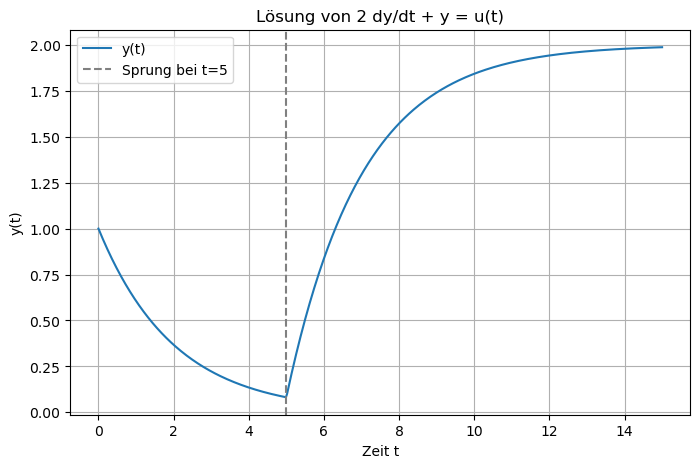

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Zeitschritte
t = np.linspace(0, 15, 500)

# Eingangssignal u(t): Sprung bei t=5 von 0 auf 2
def u(t):
    return 0 if t < 5 else 2

# Differentialgleichung: 2 dy/dt + y = u(t)
# => dy/dt = (u(t) - y)/2
def model(y, t):
    dydt = (u(t) - y) / 2
    return dydt

# Anfangsbedingung
y0 = 1

# Lösung berechnen
y = odeint(model, y0, t)

# Wert bei t = 15
y_t15 = y[-1][0]
print("y(15) =", y_t15)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, y, label='y(t)')
plt.axvline(5, linestyle='--', color='gray', label='Sprung bei t=5')
plt.xlabel('Zeit t')
plt.ylabel('y(t)')
plt.title('Lösung von 2 dy/dt + y = u(t)')
plt.legend()
plt.grid(True)
plt.show()

### TCLab-Übung

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Datenerfassung

![connections](https://apmonitor.com/che263/uploads/Begin_Python/connections.png)

Schalte Heizer 1 auf 100% und zeichne $T_1$ alle 5 Sekunden für 3 Minuten auf. Die Daten sollen insgesamt 37 Messpunkte pro Temperatursensor enthalten.

In [6]:
import numpy as np
import pandas as pd
import tclab
import time
# Erfasse Daten für 3 Minuten, alle 5 Sekunden
n = 37
tm = np.linspace(0,180,n)
t1s = np.empty(n); t2s = np.empty(n)
with tclab.TCLab() as lab:
    lab.Q1(100); lab.Q2(0)
    print('Time T1  T2')
    for i in range(n):
        t1s[i] = lab.T1; t2s[i] = lab.T2
        print(tm[i],t1s[i],t2s[i])
        time.sleep(5.0)
# in ein DataFrame übertragen
data = pd.DataFrame(np.column_stack((tm,t1s,t2s)),\
                    columns=['Time','T1','T2'])
data.to_csv('11-data.csv',index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM4 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Time T1  T2
0.0 23.315 23.477
5.0 23.412 23.477
10.0 23.509 23.477
15.0 24.121 23.477
20.0 24.766 23.477
25.0 25.539 23.541
30.0 26.699 23.799
35.0 27.666 23.831
40.0 28.955 24.089
45.0 30.276 24.411
50.0 31.662 24.669
55.0 33.145 25.023
60.0 34.434 25.378
65.0 36.013 25.732
70.0 37.334 26.055
75.0 38.913 26.57
80.0 40.234 27.021
85.0 41.749 27.473
90.0 43.135 28.021
95.0 44.424 28.633
100.0 45.713 29.213
105.0 47.002 29.664
110.0 48.291 30.244
115.0 49.58 30.889
120.0 50.708 31.533
125.0 51.868 32.178
130.0 53.125 32.822
135.0 54.092 33.467
140.0 55.349 34.111
145.0 56.348 34.756
150.0 57.314 35.368
155.0 58.281 36.013
160.0 59.216 36.657
165.0 60.118 37.076
170.0 60.859 37.656
175.0 61.826 38.301
180.0 62.535 38.945
TCLab disconnected successfully.


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Differentialgleichung lösen

Verwende die Parameter `a`, `b`, und `c` aus Kapitel [10. Gleichungen lösen](https://github.com/APMonitor/data_science/blob/master/10.%20Solve_Equations.ipynb)
**///Hier das Kapitel / Notebook verlinken**
oder die folgenden Standardwerte:

| Parameter | Wert |
|------|------|
| a    | 78.6 |
| b    | -50.3 |
| c    | -0.003677 |

Löse damit die gewöhnliche Differentialgleichung (ODE)

$\frac{dT_1}{dt} = c (T_1-a)$

Die Anfangsbedingung für $T_1$ ist $a + b$. Zeige die ODE-Lösung für Zeitpunkte zwischen `0` und `180` s und plotte die gemessenen $T_1$-Werte im selben Diagramm wie die ODE-Vorhersage. Füge passende Achsenbeschriftungen und eine Legende hinzu.

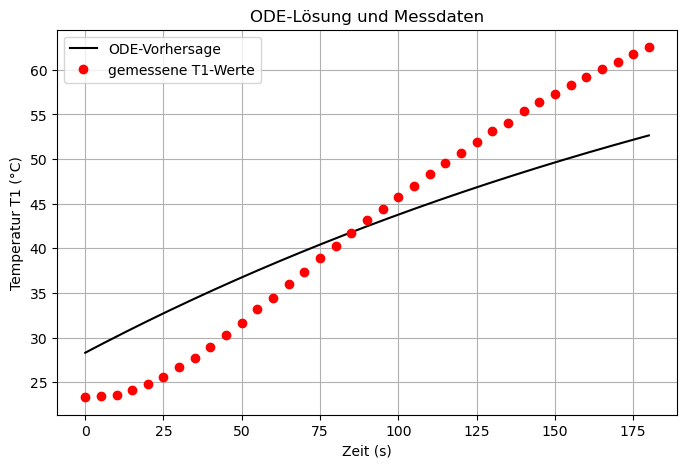

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter (Standardwerte aus der Aufgabe)
a = 78.6
b = -50.3
c = -0.003677

# Anfangsbedingung
T1_0 = a + b  # T1(0)

# Zeitpunkte 0 ... 180 (Sekunden)
t = np.linspace(0, 180, 181)

# ODE: dT1/dt = c * (T1 - a)
# Analytische Lösung: T1(t) = a + (T1_0 - a) * exp(c*t)
T1_ode = a + (T1_0 - a) * np.exp(c * t)

# Messdaten (falls vorhanden): data oder df mit Spalten 'Time' und 'T1'
# -> Falls dein DataFrame anders heißt, ersetze unten 'data' entsprechend.
plt.figure(figsize=(8,5))
plt.plot(t, T1_ode, "k-", label="ODE-Vorhersage")

if "data" in globals() and ("Time" in data.columns) and ("T1" in data.columns):
    plt.plot(data["Time"], data["T1"], "ro", label="gemessene T1-Werte")

plt.xlabel("Zeit (s)")
plt.ylabel("Temperatur T1 (°C)")
plt.title("ODE-Lösung und Messdaten")
plt.grid(True)
plt.legend()
plt.show()